In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import impute
from itertools import product
import missingno as msno
from sksurv.ensemble import RandomSurvivalForest
from sklearn.model_selection import train_test_split
from sksurv.util import Surv

In [2]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    nacc_data_csv = "/content/drive/MyDrive/bachelor/nacc_data_2025.csv"
else:
    nacc_data_csv = "nacc_data_2025.csv"

In [3]:
nacc_raw = pd.read_csv(nacc_data_csv, delimiter='\t')

/var/folders/g9/j9c8b7vs3m3frqcxprr6hf900000gn/T/ipykernel_2812/2964923166.py:1: DtypeWarning: Columns (8,10,12,14,25,29,31,40,42,44,46,48,50,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,142,194,197,199,205,207,209,211,213,215,219,221,223,225,227,229,231,233,235,237,239,241,243,245,247,249,374,376,378,396,398,409,422,429,469,549,572,580,605,640,673,676,693,704,710,763,765,766,767,768,774,797,809,810,818,819,820,821,831,853,856,859) have mixed types. Specify dtype option on import or set low_memory=False.
  nacc_raw = pd.read_csv(nacc_data_csv, delimiter='\t')


In [4]:
nacc_raw.head()

,NACCID,VISITMO,VISITDAY,VISITYR,NACCREFR,SEX,HISPANIC,HISPOR,HISPORX,RACE,...,NPCOTH1,NPOTH1X,NPPOTH2,NPCOTH2,NPOTH2X,NPPOTH3,NPCOTH3,NPOTH3X,EVENT_MCI,TIME
0,NACC004687,11,14,2022,2.0,1,1.0,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.806982
1,NACC021466,5,16,2023,2.0,2,1.0,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.108830
2,NACC023914,11,16,2023,1.0,1,0.0,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.084189
3,NACC038914,8,11,2022,2.0,1,1.0,1.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.527721
4,NACC048580,10,19,2023,2.0,2,0.0,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.086927


In [5]:
nacc_raw.duplicated().sum()

np.int64(0)

In [6]:
len(nacc_raw.columns.tolist())

862

In [7]:
nacc_raw['AMYLCSF'].isnull().sum()

np.int64(10035)

In [8]:
nacc_raw['CSFTAU'].isnull().sum()

np.int64(10035)

In [9]:
nacc_raw['FDGFTLD'].isnull().sum()

np.int64(10035)

In [10]:
common_biomarkes_with_high_nan = nacc_raw[['AMYLCSF', 'CSFTAU', 'FDGFTLD']]

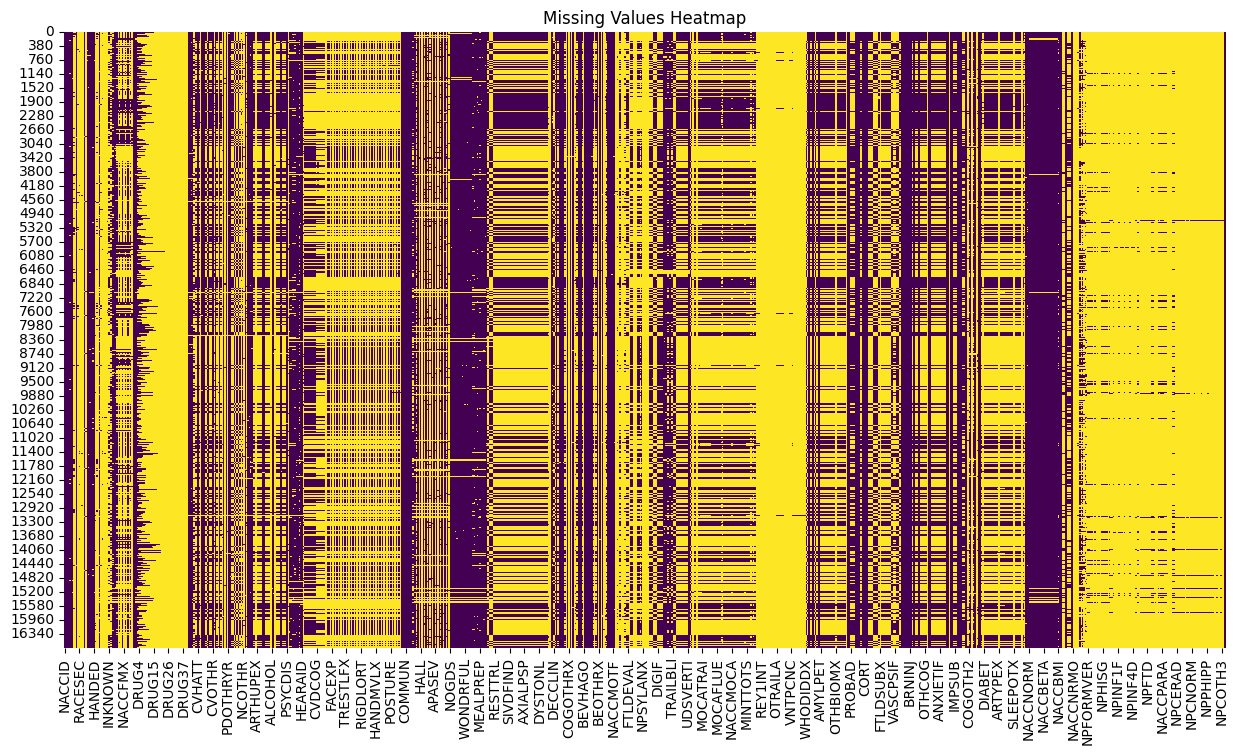

In [11]:
plt.figure(figsize=(15, 8))
sns.heatmap(nacc_raw.isna(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [12]:
len(nacc_raw.columns.tolist())

862

In [13]:
nan_nacc_percentage = nacc_raw.isna().sum() / len(nacc_raw) * 100
columns_with_significant_amount_of_nan = nan_nacc_percentage[nan_nacc_percentage > 80].index.tolist()
print(f"Columns with 80%+ number of missing values: {len(columns_with_significant_amount_of_nan)}")

Columns with 80%+ number of missing values: 301


In [14]:
cleaned_nacc = nacc_raw.drop(columns=columns_with_significant_amount_of_nan)
len(cleaned_nacc.columns.tolist())

561

In [15]:
columns_with_small_amount_of_nan = nan_nacc_percentage[nan_nacc_percentage < 20].index.tolist()
print(f"Columns with < 20% number of missing values: {len(columns_with_significant_amount_of_nan)}")

Columns with < 20% number of missing values: 301


In [16]:
cleaned_nacc_nan = cleaned_nacc.drop(columns=columns_with_small_amount_of_nan)
len(cleaned_nacc_nan.columns.tolist())

348

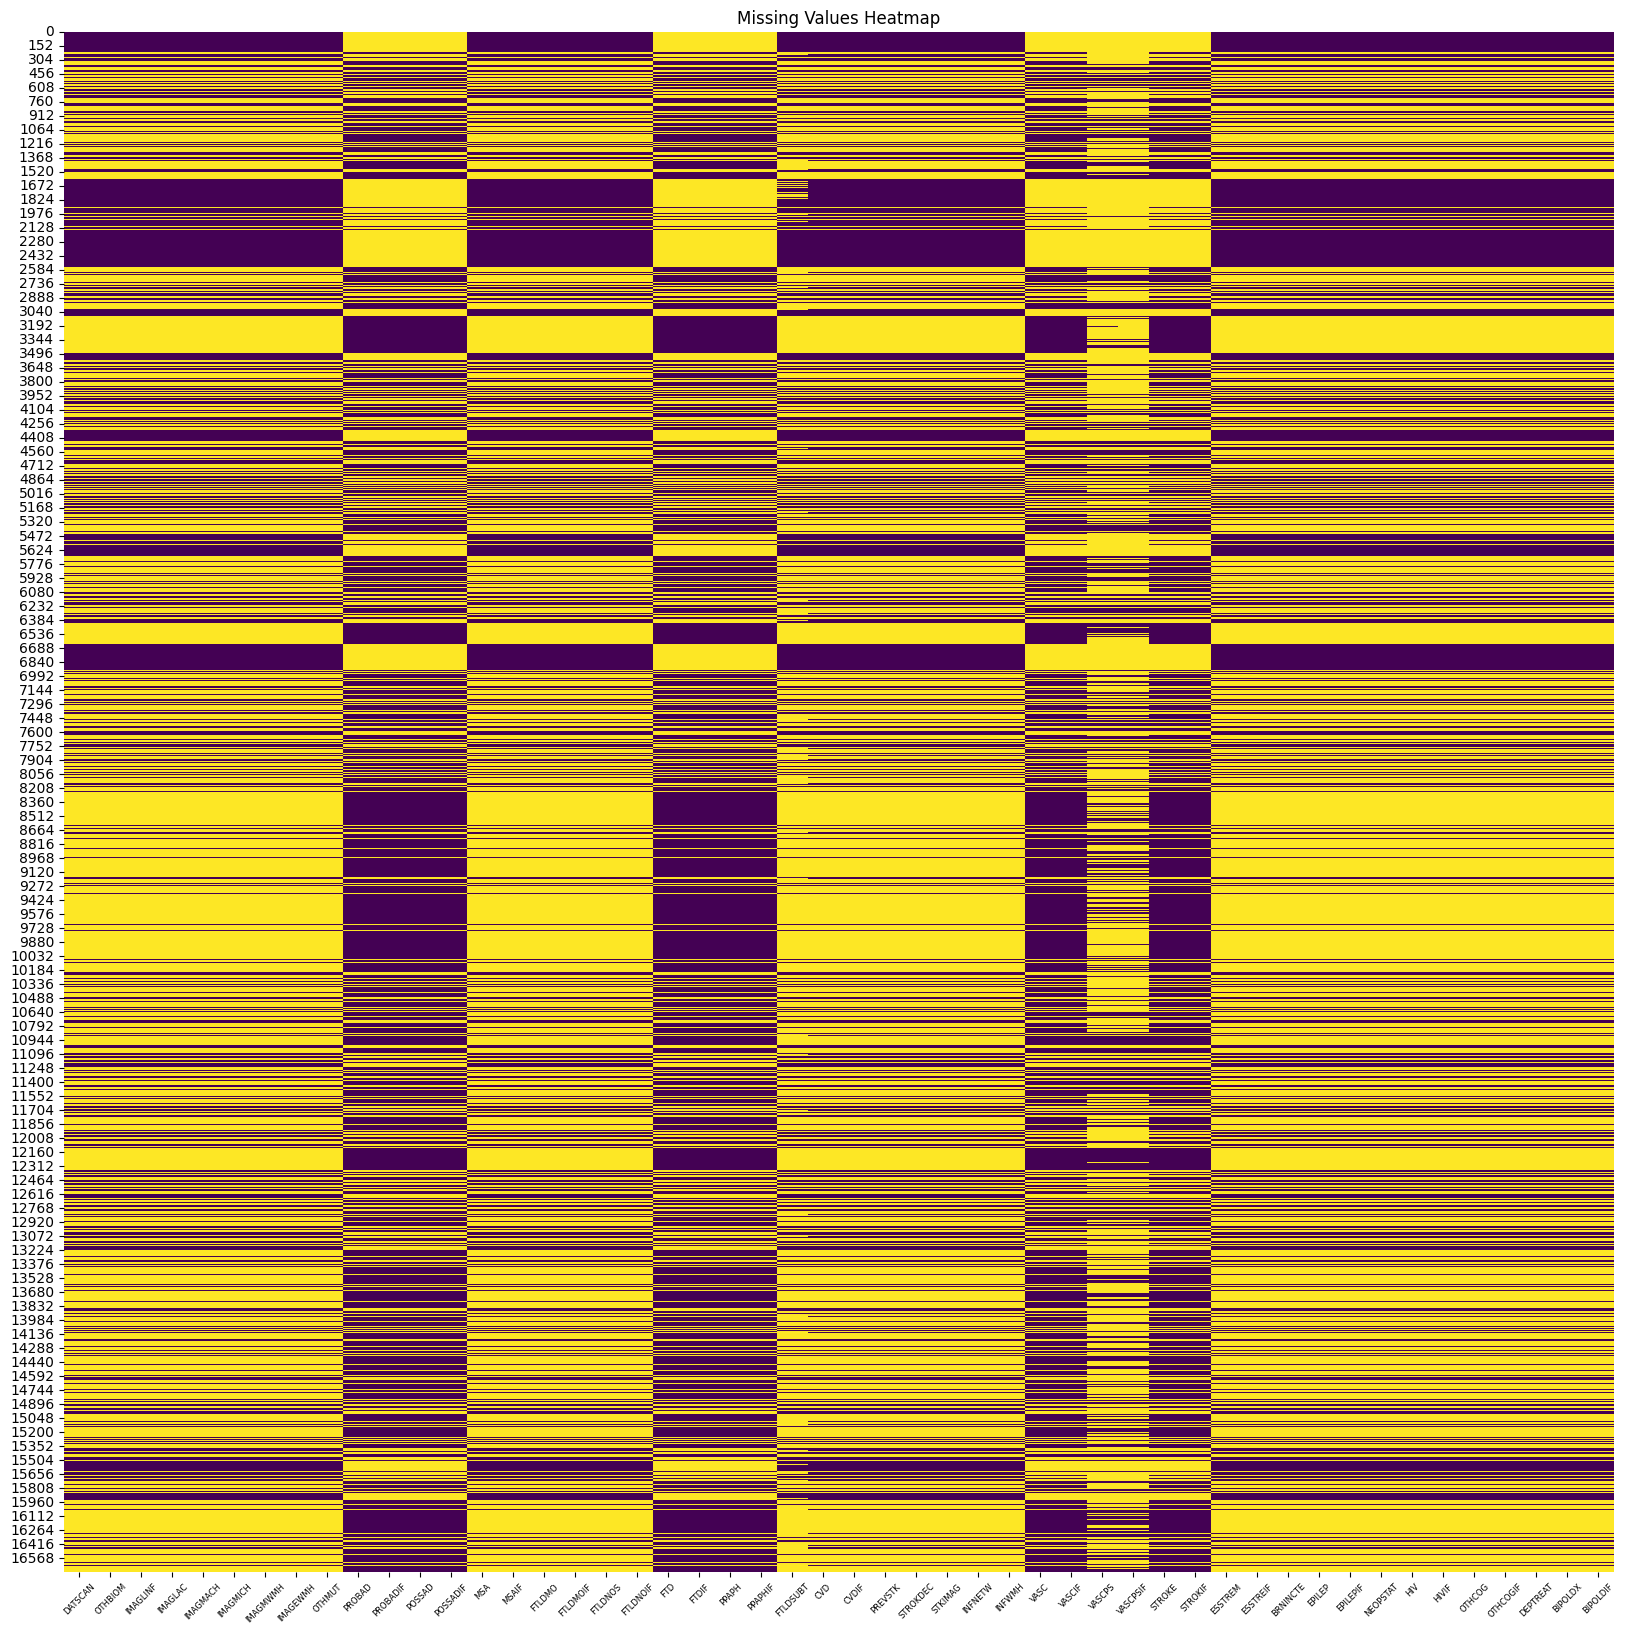

In [17]:
plt.figure(figsize=(20, 20))
sns.heatmap(cleaned_nacc_nan.iloc[:, -100:-50].isna(), cbar=False, cmap='viridis')
plt.xticks(rotation=45, fontsize=6)
plt.title('Missing Values Heatmap')
plt.show()

In [18]:
cleaned_nacc_nan_dependency_df = cleaned_nacc_nan.drop(columns=['VASCPS', "VASCPSIF", 'FTLDSUBT', 'MOCARECC', 'NACCMOCA', 'CRAFTDTI', 'CRAFTCUE', 'MINTTOTS', 'MINTTOTW', 'MINTSCNC', 'MINTPCNC', 'MINTSCNG', 'MINTSCNC', 'MINTPCNG'])

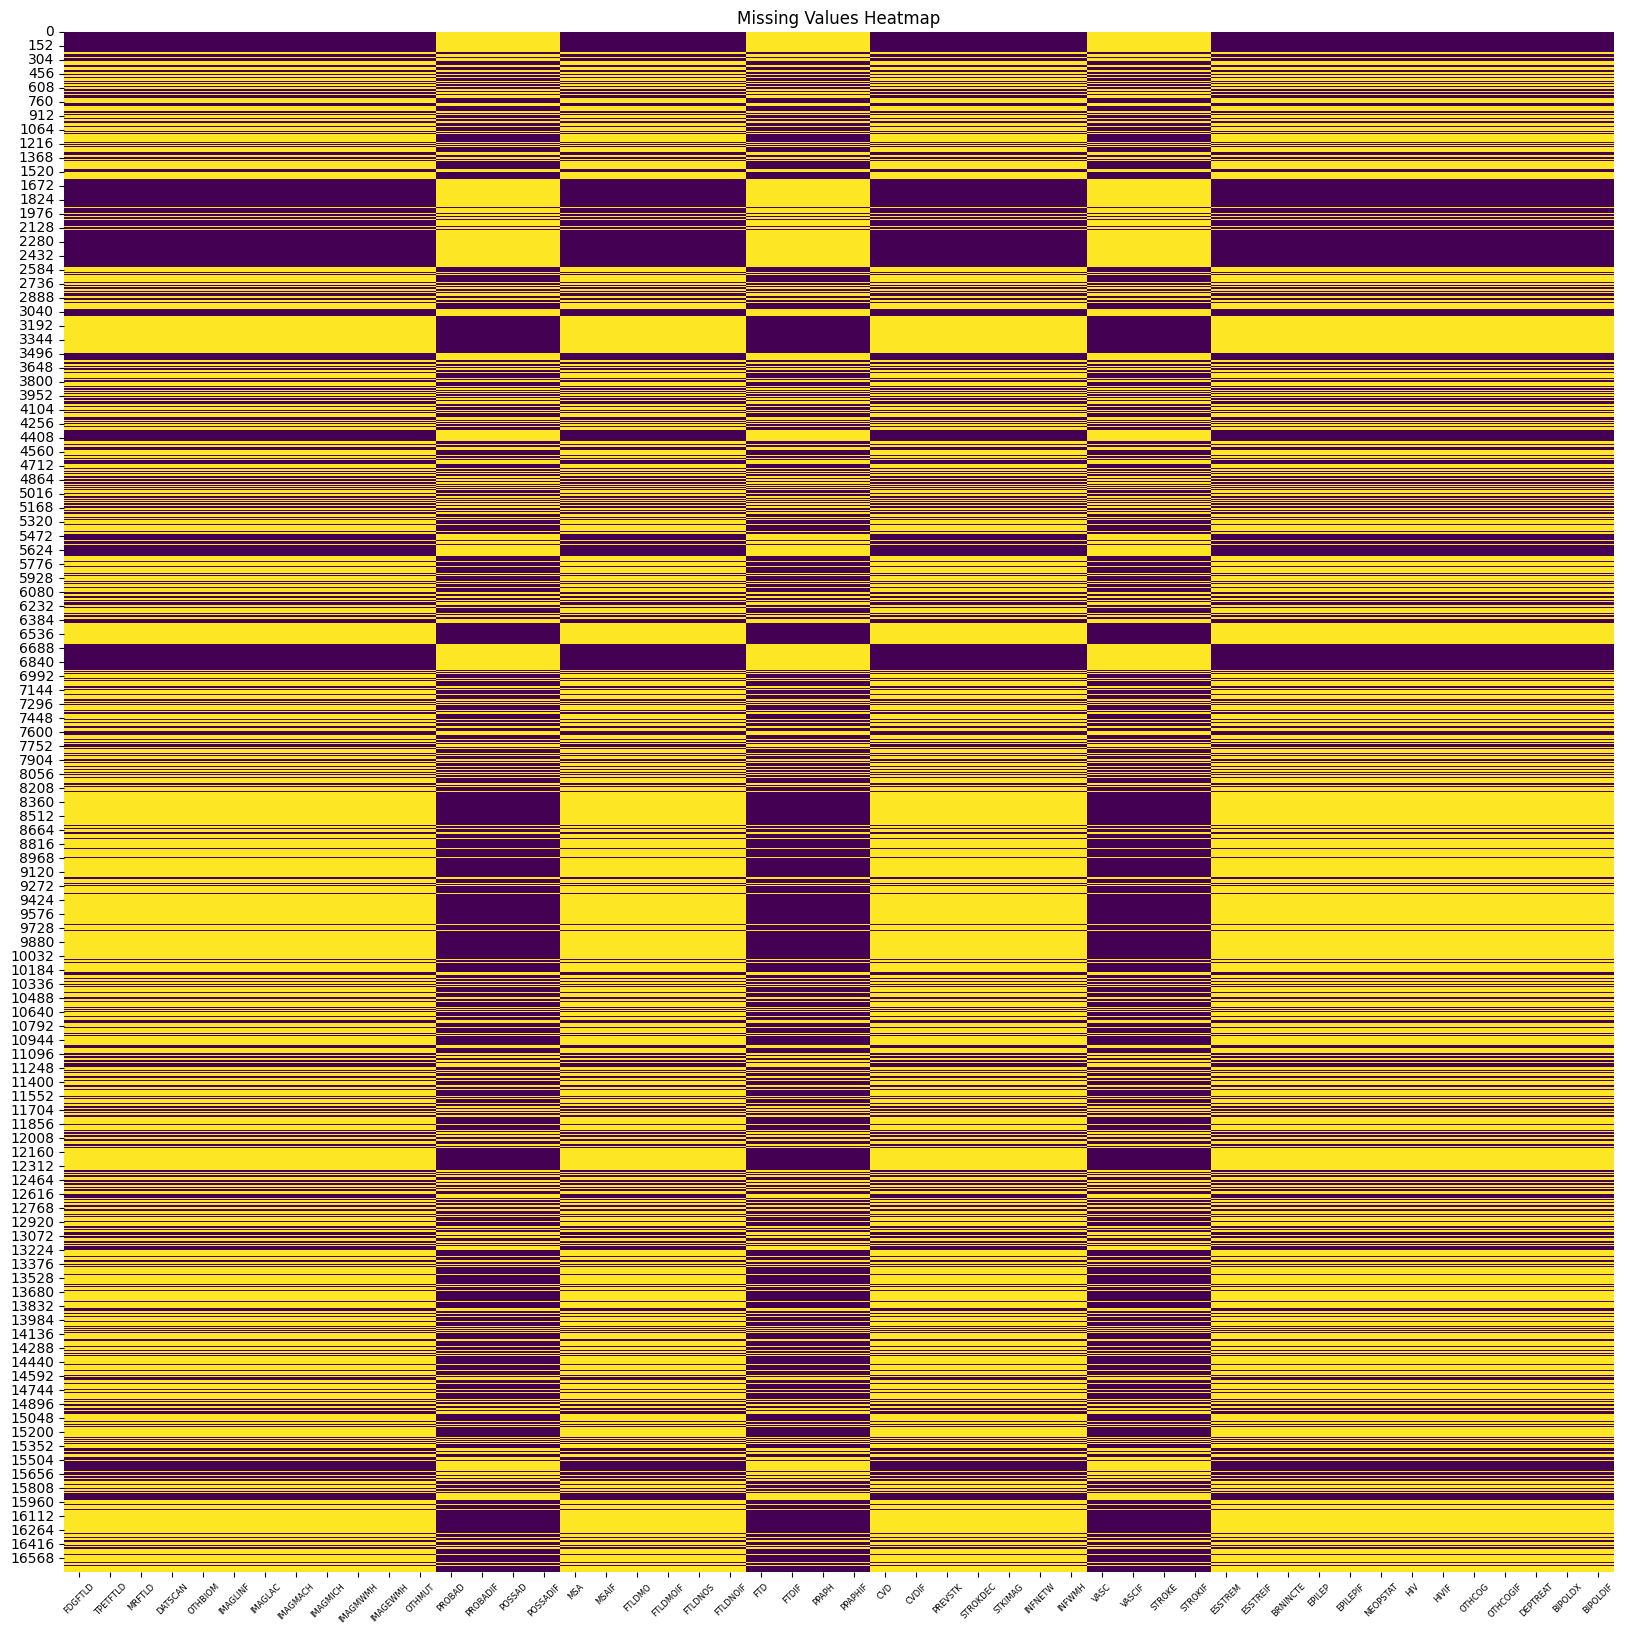

In [19]:
plt.figure(figsize=(20, 20))
sns.heatmap(cleaned_nacc_nan_dependency_df.iloc[:, -100:-50].isna(), cbar=False, cmap='viridis')
plt.xticks(rotation=45, fontsize=6)
plt.title('Missing Values Heatmap')
plt.show()

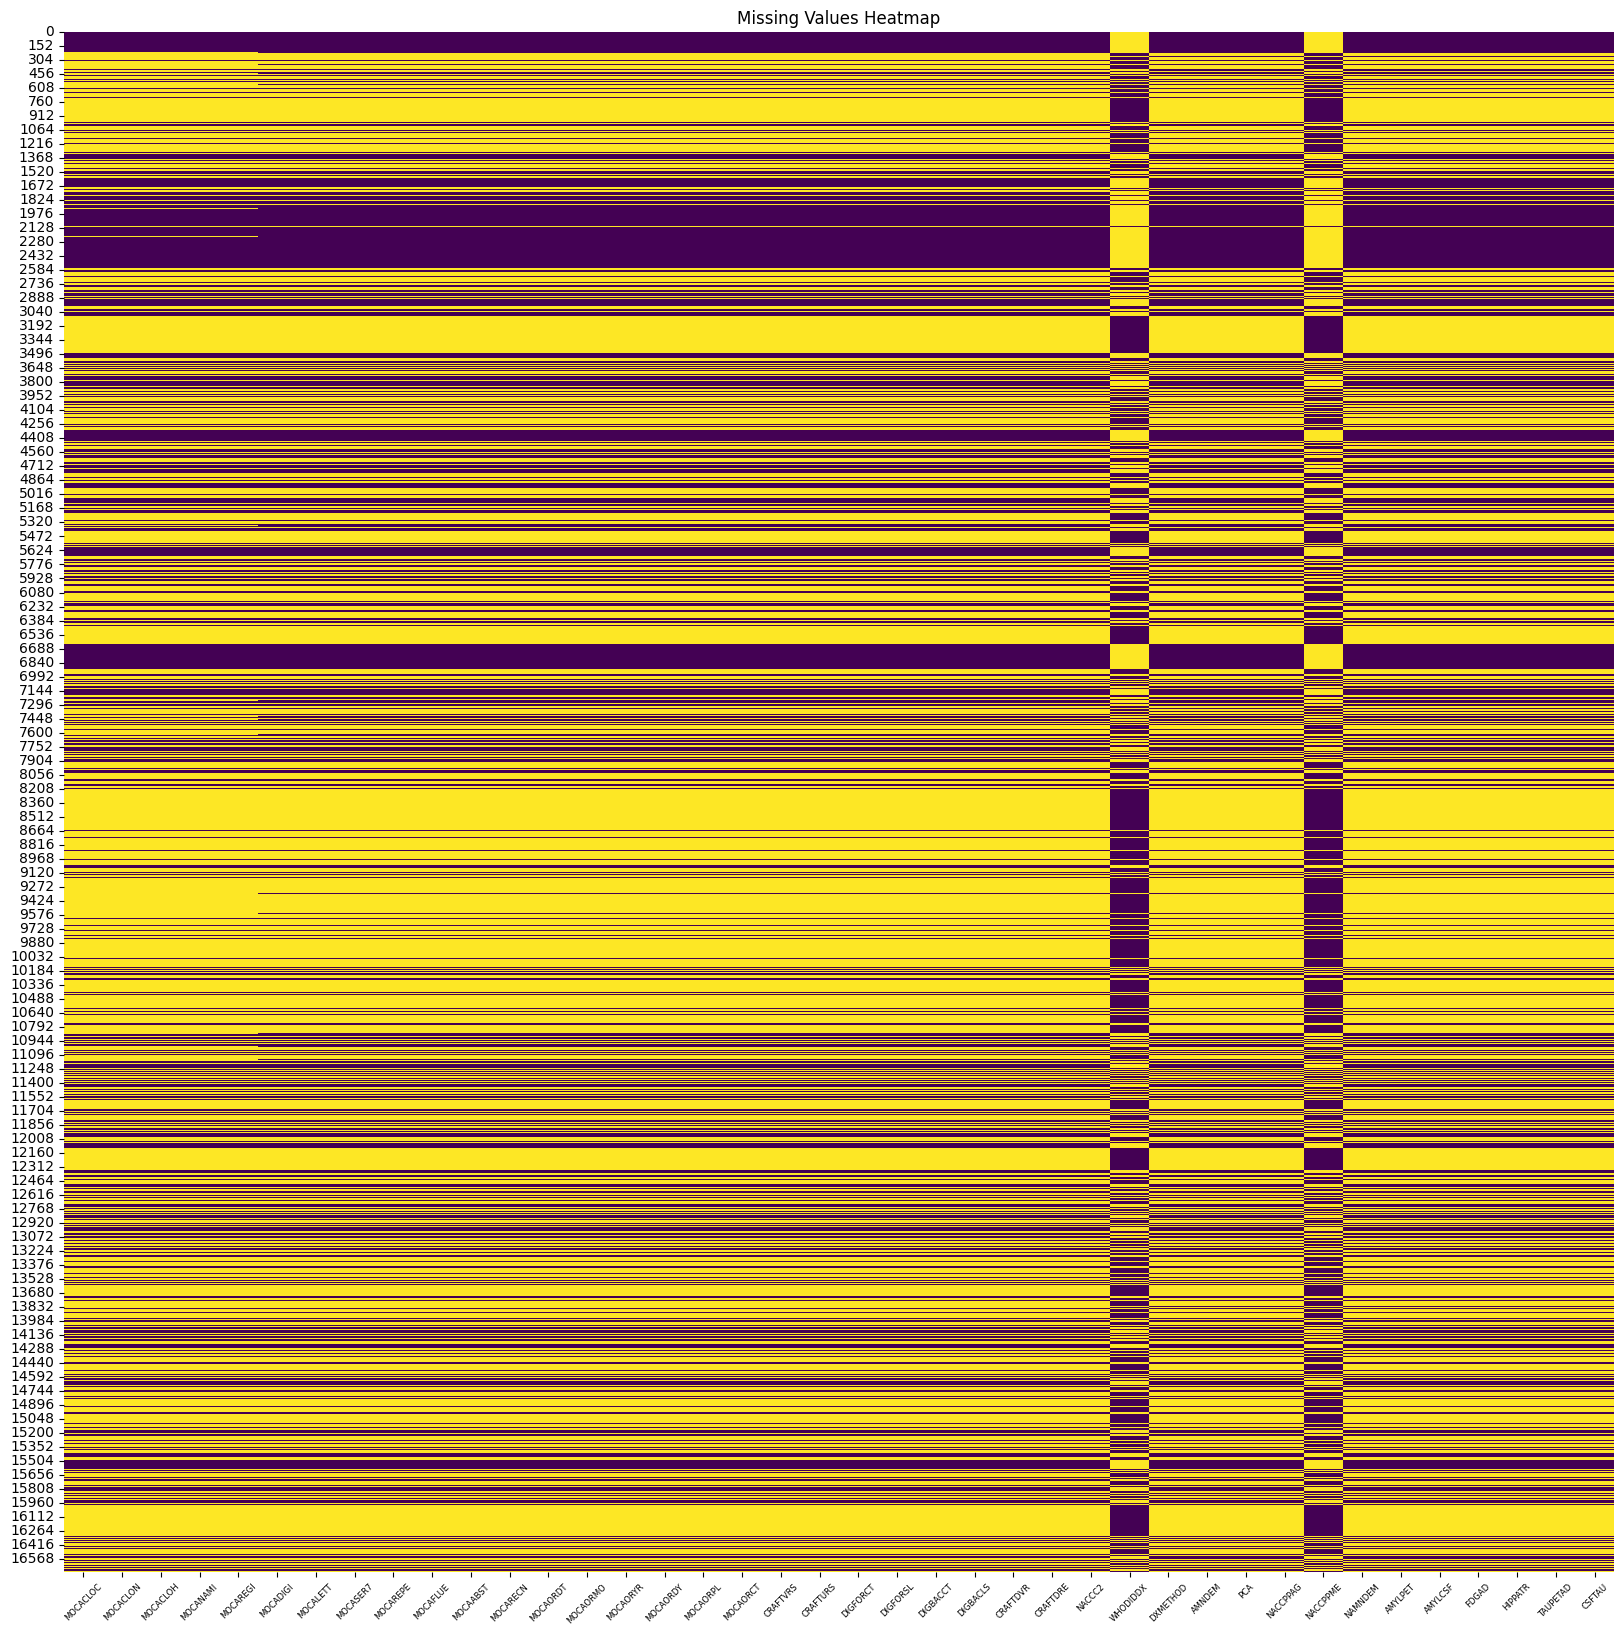

In [20]:
plt.figure(figsize=(20, 20))
sns.heatmap(cleaned_nacc_nan_dependency_df.iloc[:, -140:-100].isna(), cbar=False, cmap='viridis')
plt.xticks(rotation=45, fontsize=6)
plt.title('Missing Values Heatmap')
plt.show()

In [21]:
# 'AMYLCSF', 'CSFTAU', 'FDGFTLD' - these biomarkers are often associated with AD which could be useful for the detection MCI
# I noticed that, there is a patter in the missigness of values and wanted to create a subdataset with these values and others to detect probably the dependency
# to possibly recover the data
cleaned_nacc_nan_dependency_df.iloc[:, -130:-50].columns

Index(['MOCAABST', 'MOCARECN', 'MOCAORDT', 'MOCAORMO', 'MOCAORYR', 'MOCAORDY',
       'MOCAORPL', 'MOCAORCT', 'CRAFTVRS', 'CRAFTURS', 'DIGFORCT', 'DIGFORSL',
       'DIGBACCT', 'DIGBACLS', 'CRAFTDVR', 'CRAFTDRE', 'NACCC2', 'WHODIDDX',
       'DXMETHOD', 'AMNDEM', 'PCA', 'NACCPPAG', 'NACCPPME', 'NAMNDEM',
       'AMYLPET', 'AMYLCSF', 'FDGAD', 'HIPPATR', 'TAUPETAD', 'CSFTAU',
       'FDGFTLD', 'TPETFTLD', 'MRFTLD', 'DATSCAN', 'OTHBIOM', 'IMAGLINF',
       'IMAGLAC', 'IMAGMACH', 'IMAGMICH', 'IMAGMWMH', 'IMAGEWMH', 'OTHMUT',
       'PROBAD', 'PROBADIF', 'POSSAD', 'POSSADIF', 'MSA', 'MSAIF', 'FTLDMO',
       'FTLDMOIF', 'FTLDNOS', 'FTLDNOIF', 'FTD', 'FTDIF', 'PPAPH', 'PPAPHIF',
       'CVD', 'CVDIF', 'PREVSTK', 'STROKDEC', 'STKIMAG', 'INFNETW', 'INFWMH',
       'VASC', 'VASCIF', 'STROKE', 'STROKIF', 'ESSTREM', 'ESSTREIF',
       'BRNINCTE', 'EPILEP', 'EPILEPIF', 'NEOPSTAT', 'HIV', 'HIVIF', 'OTHCOG',
       'OTHCOGIF', 'DEPTREAT', 'BIPOLDX', 'BIPOLDIF'],
      dtype='object')

In [22]:
cleaned_nacc_nan_dependency_df = cleaned_nacc_nan_dependency_df.iloc[:, -130:-50]

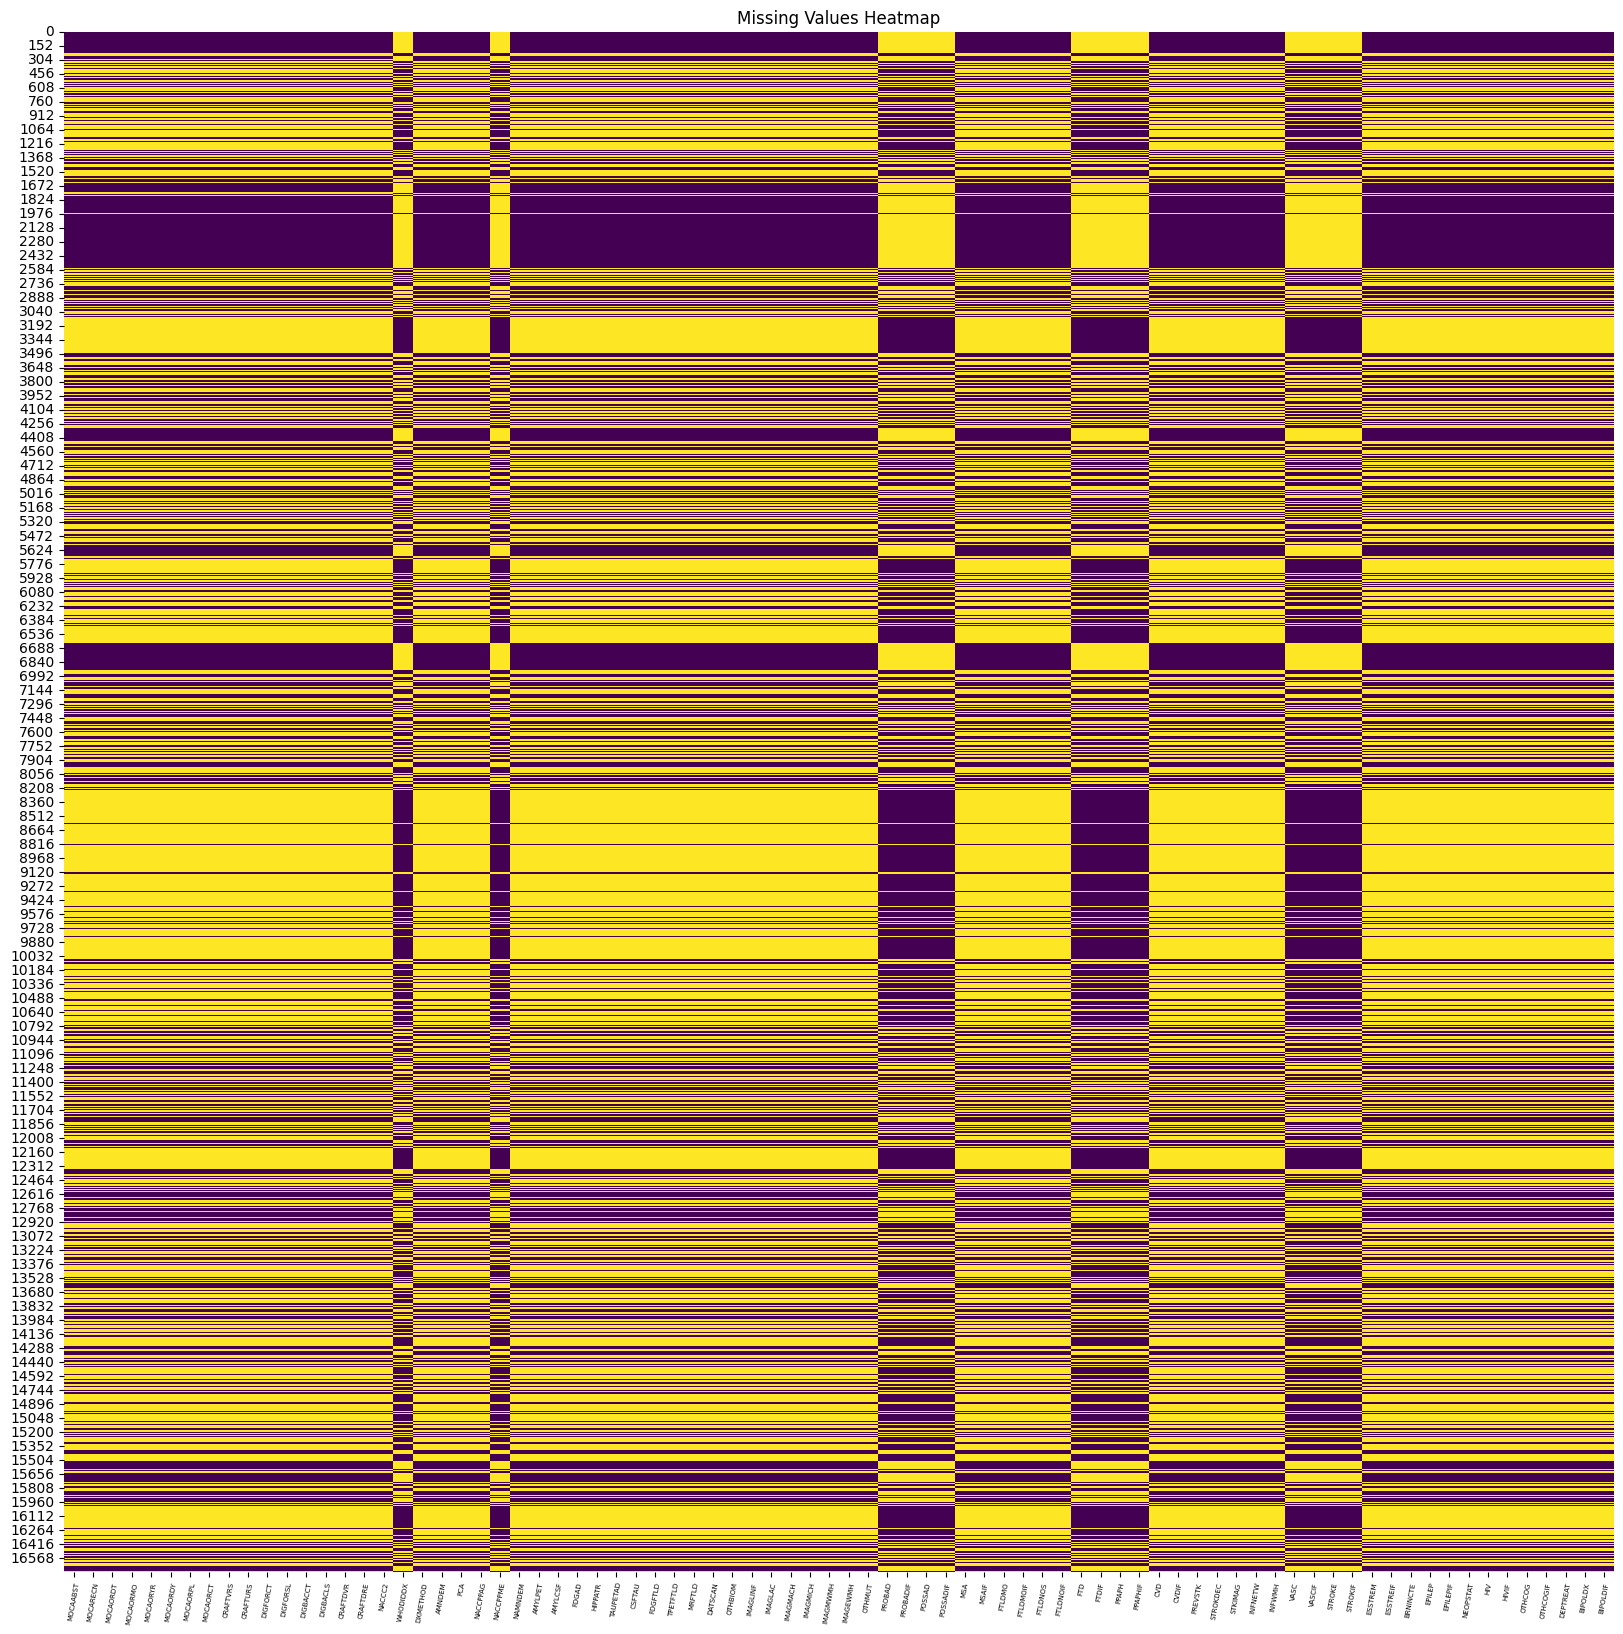

In [23]:
plt.figure(figsize=(20, 20))
sns.heatmap(cleaned_nacc_nan_dependency_df.isna(), cbar=False, cmap='viridis')
plt.xticks(rotation=80, fontsize=5)
plt.title('Missing Values Heatmap')
plt.show()

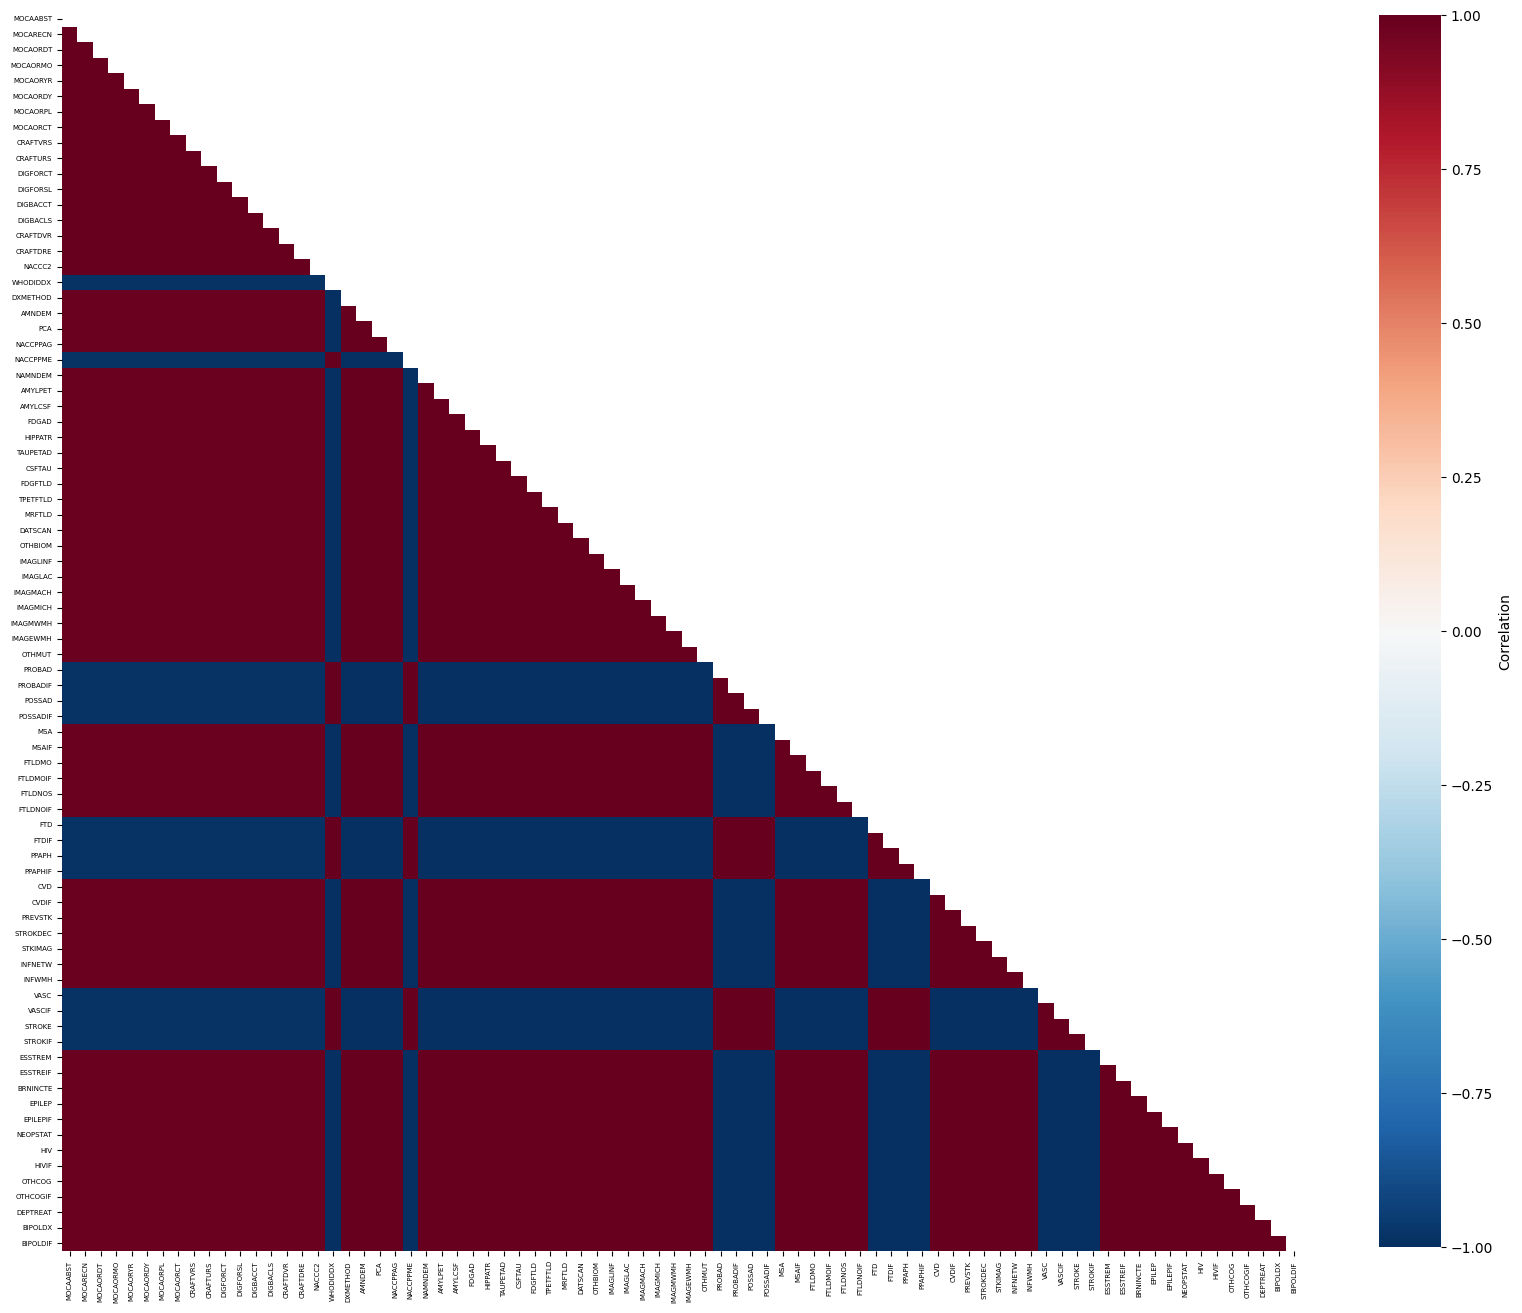

In [24]:
nan_corr = cleaned_nacc_nan_dependency_df.isnull().corr()

plt.figure(figsize=(20, 20))
mask = np.triu(np.ones_like(nan_corr, dtype=bool))
sns.heatmap(nan_corr, mask=mask, cmap='RdBu_r', center=0, square=True, cbar_kws={'shrink': 0.8, 'label': 'Correlation'})
plt.xticks(rotation=90, fontsize=5)
plt.yticks(rotation=0, fontsize=5)
plt.show()

In [25]:
cleaned_nacc_corr = cleaned_nacc_nan.isnull().corr()
the_same_pattern_df = cleaned_nacc_corr['AMYLCSF'][cleaned_nacc_corr['AMYLCSF'] >= 0.99999]
the_opposite_pattern_df = cleaned_nacc_corr['AMYLCSF'][cleaned_nacc_corr['AMYLCSF'] <= -0.99999]

same_pattern_columns = the_same_pattern_df.reset_index()['index'].tolist()
opposite_pattern_columns = the_opposite_pattern_df.reset_index()['index'].tolist()

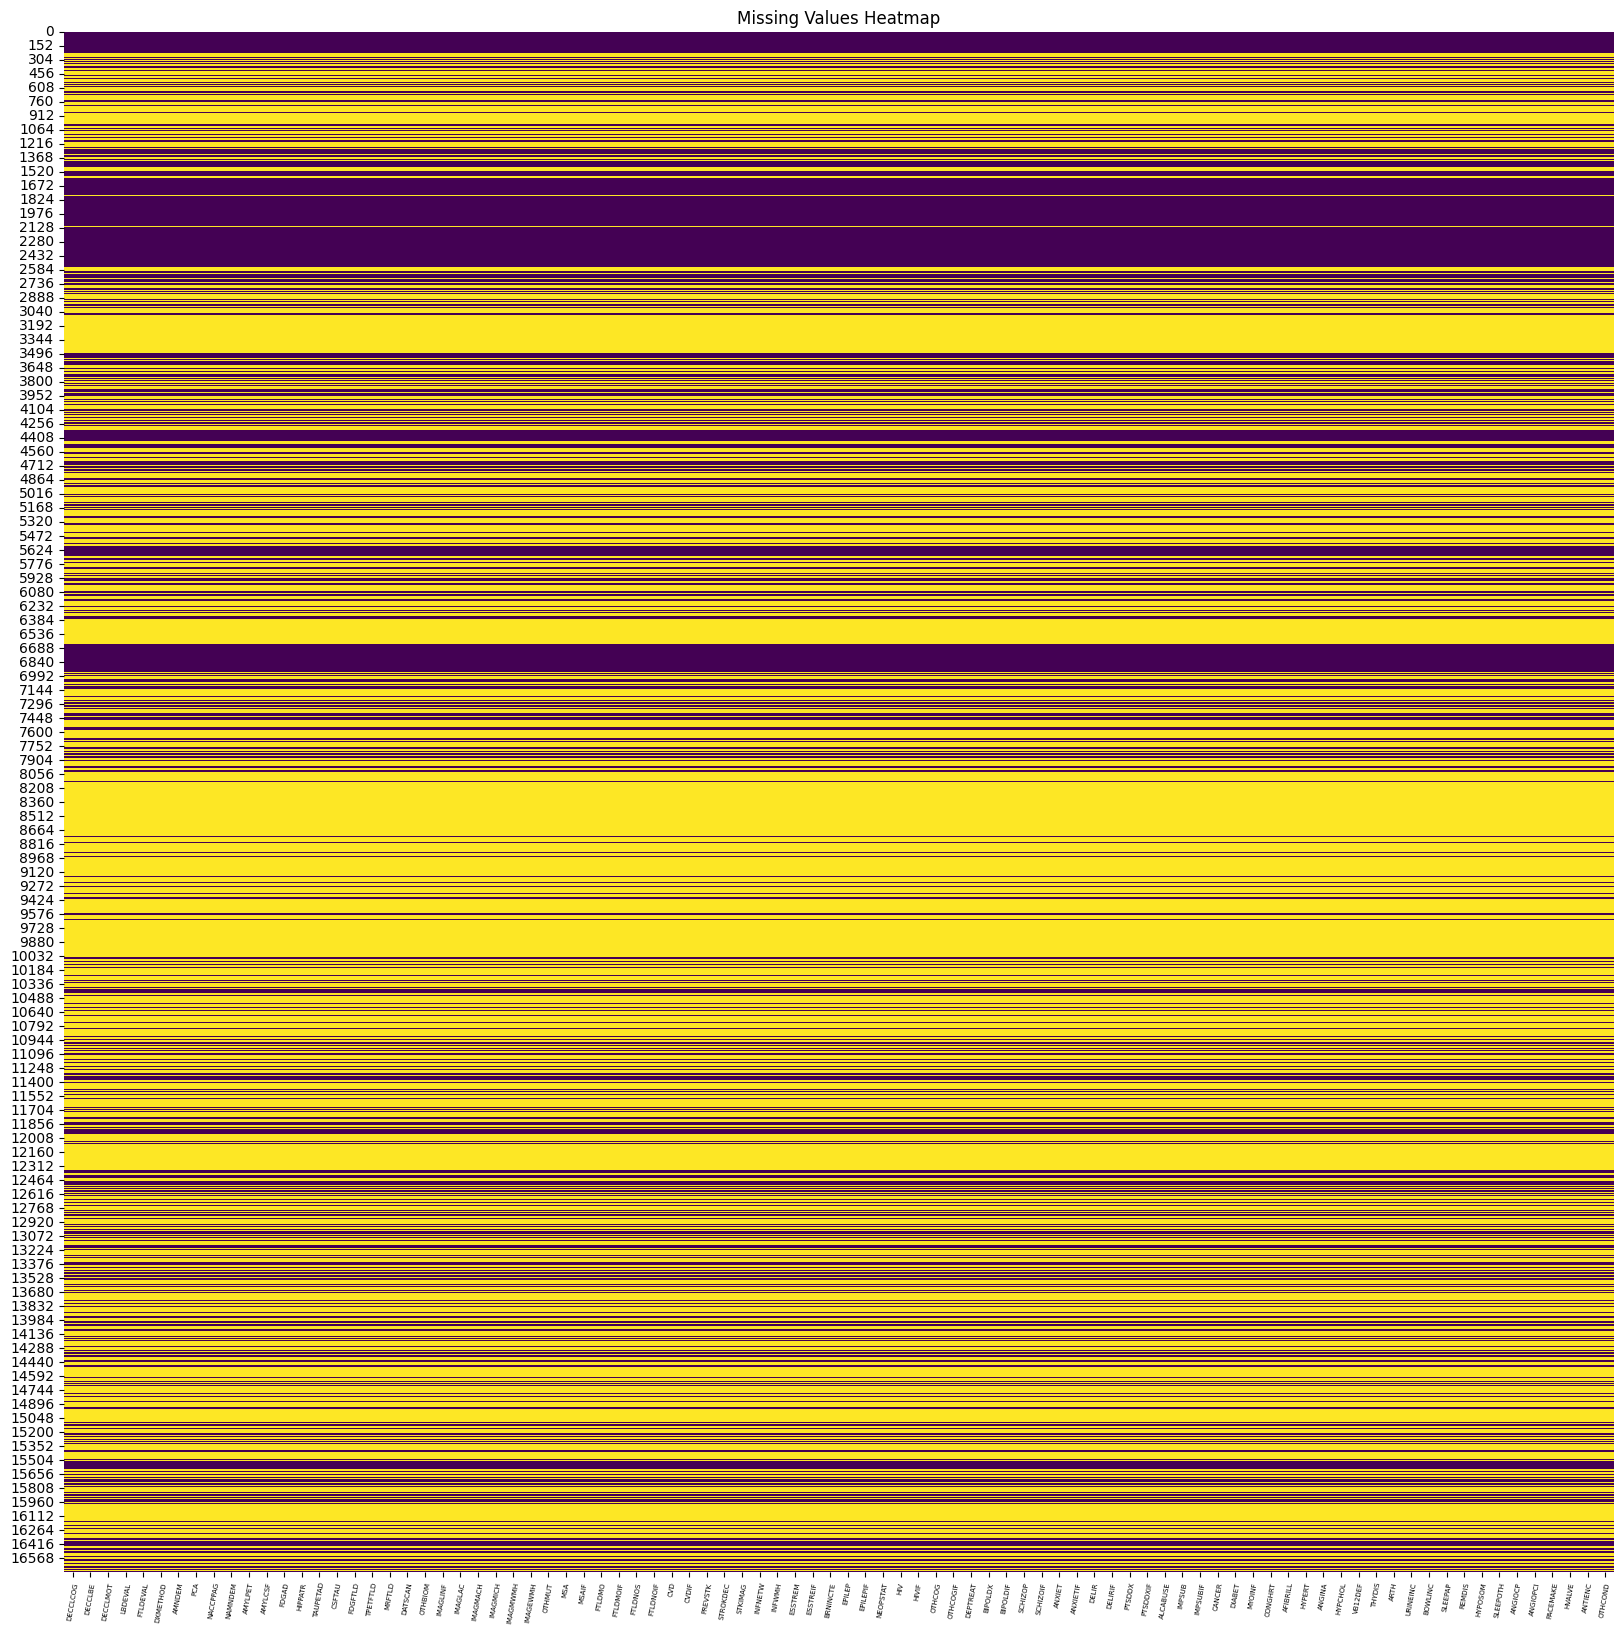

In [26]:
plt.figure(figsize=(20, 20))
sns.heatmap(cleaned_nacc_nan[same_pattern_columns].isna(), cbar=False, cmap='viridis')
plt.xticks(rotation=80, fontsize=5)
plt.title('Missing Values Heatmap')
plt.show()

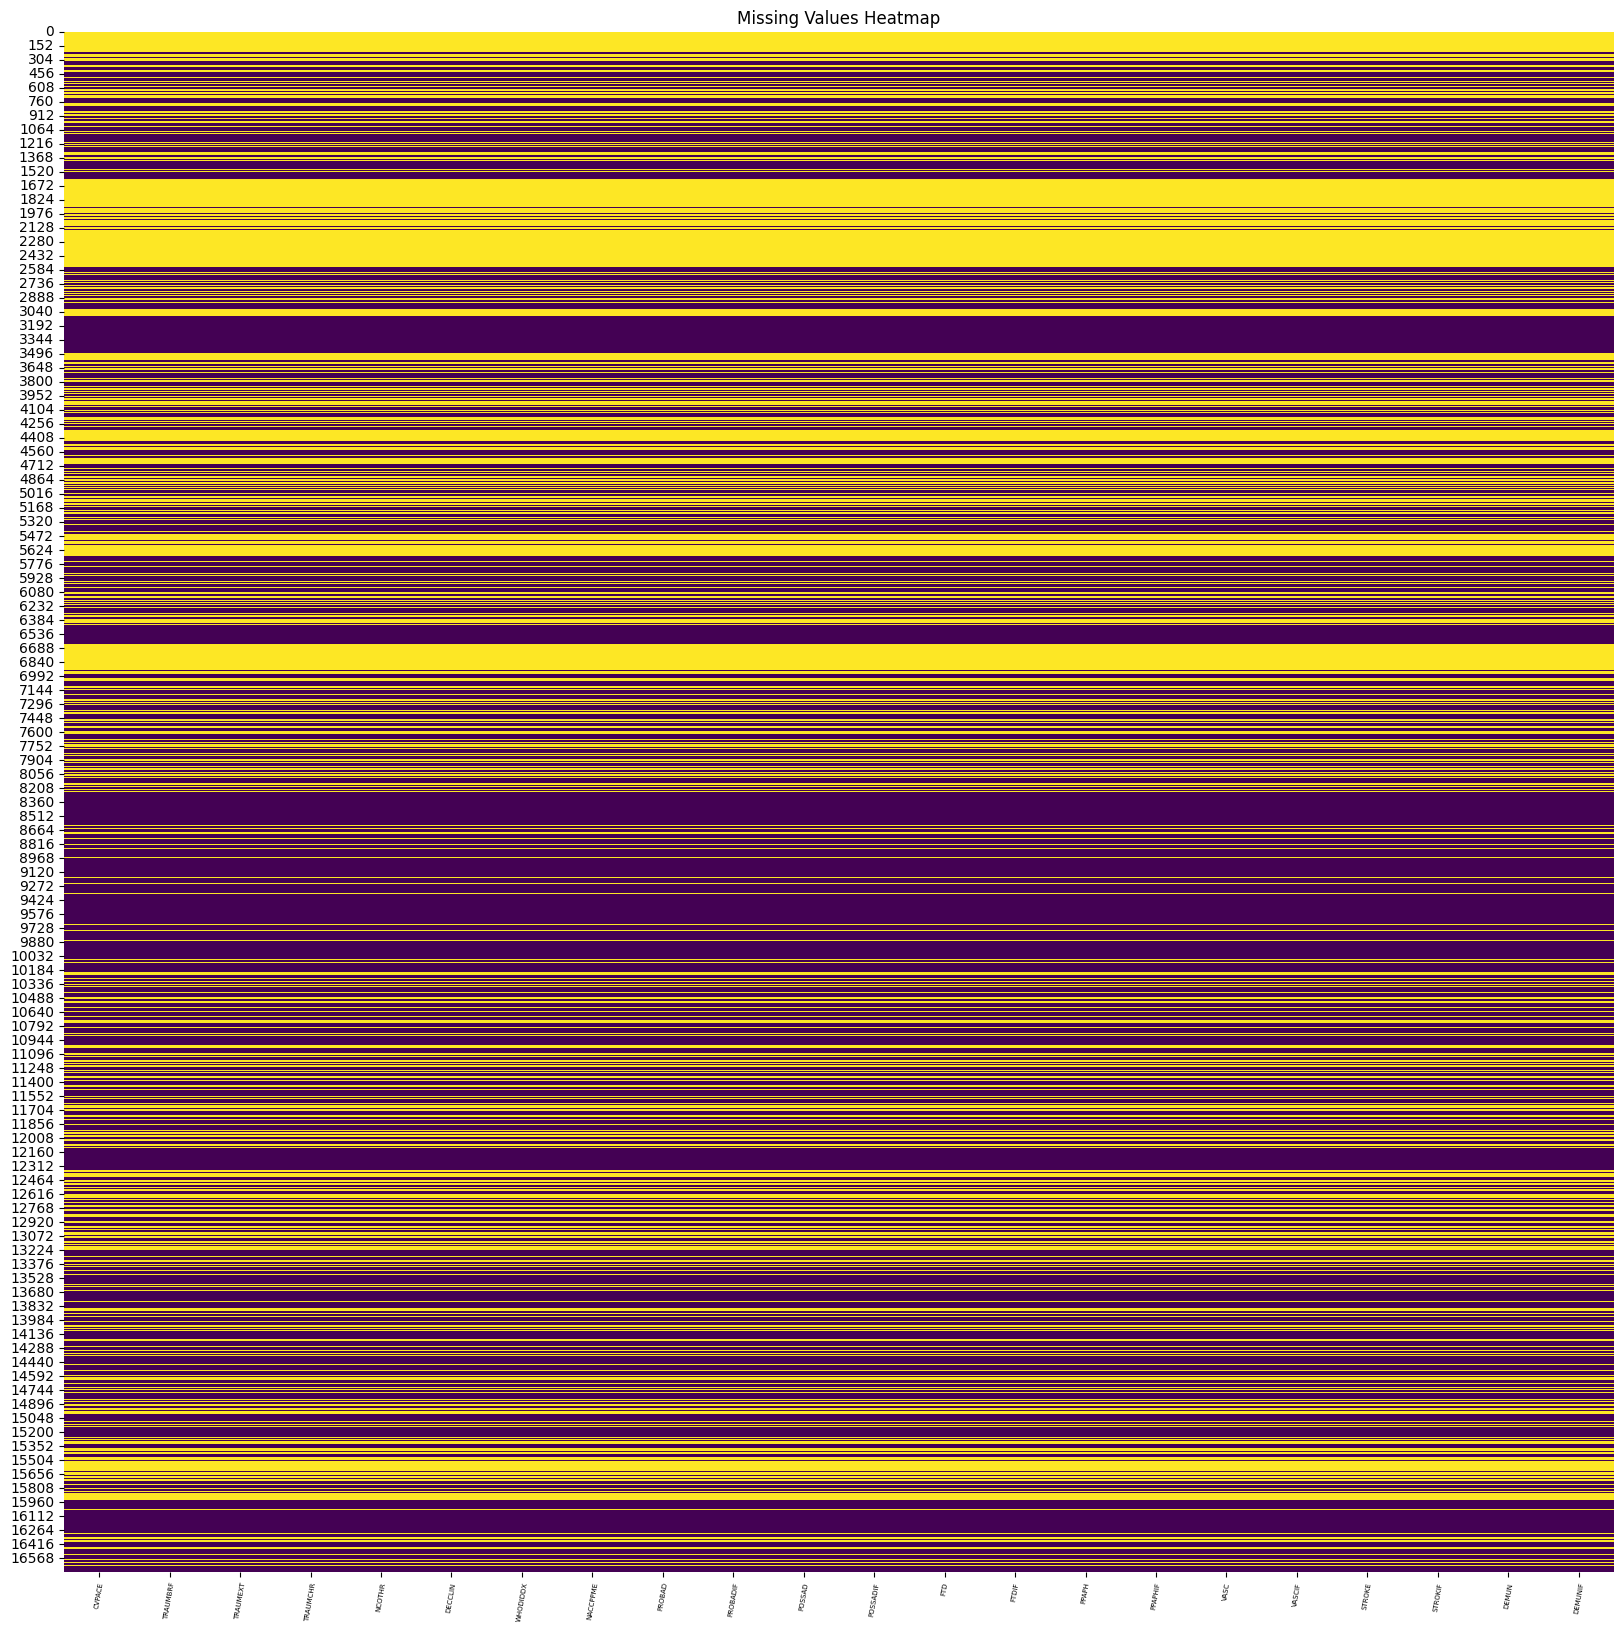

In [27]:
plt.figure(figsize=(20, 20))
sns.heatmap(cleaned_nacc_nan[opposite_pattern_columns].isna(), cbar=False, cmap='viridis')
plt.xticks(rotation=80, fontsize=5)
plt.title('Missing Values Heatmap')
plt.show()

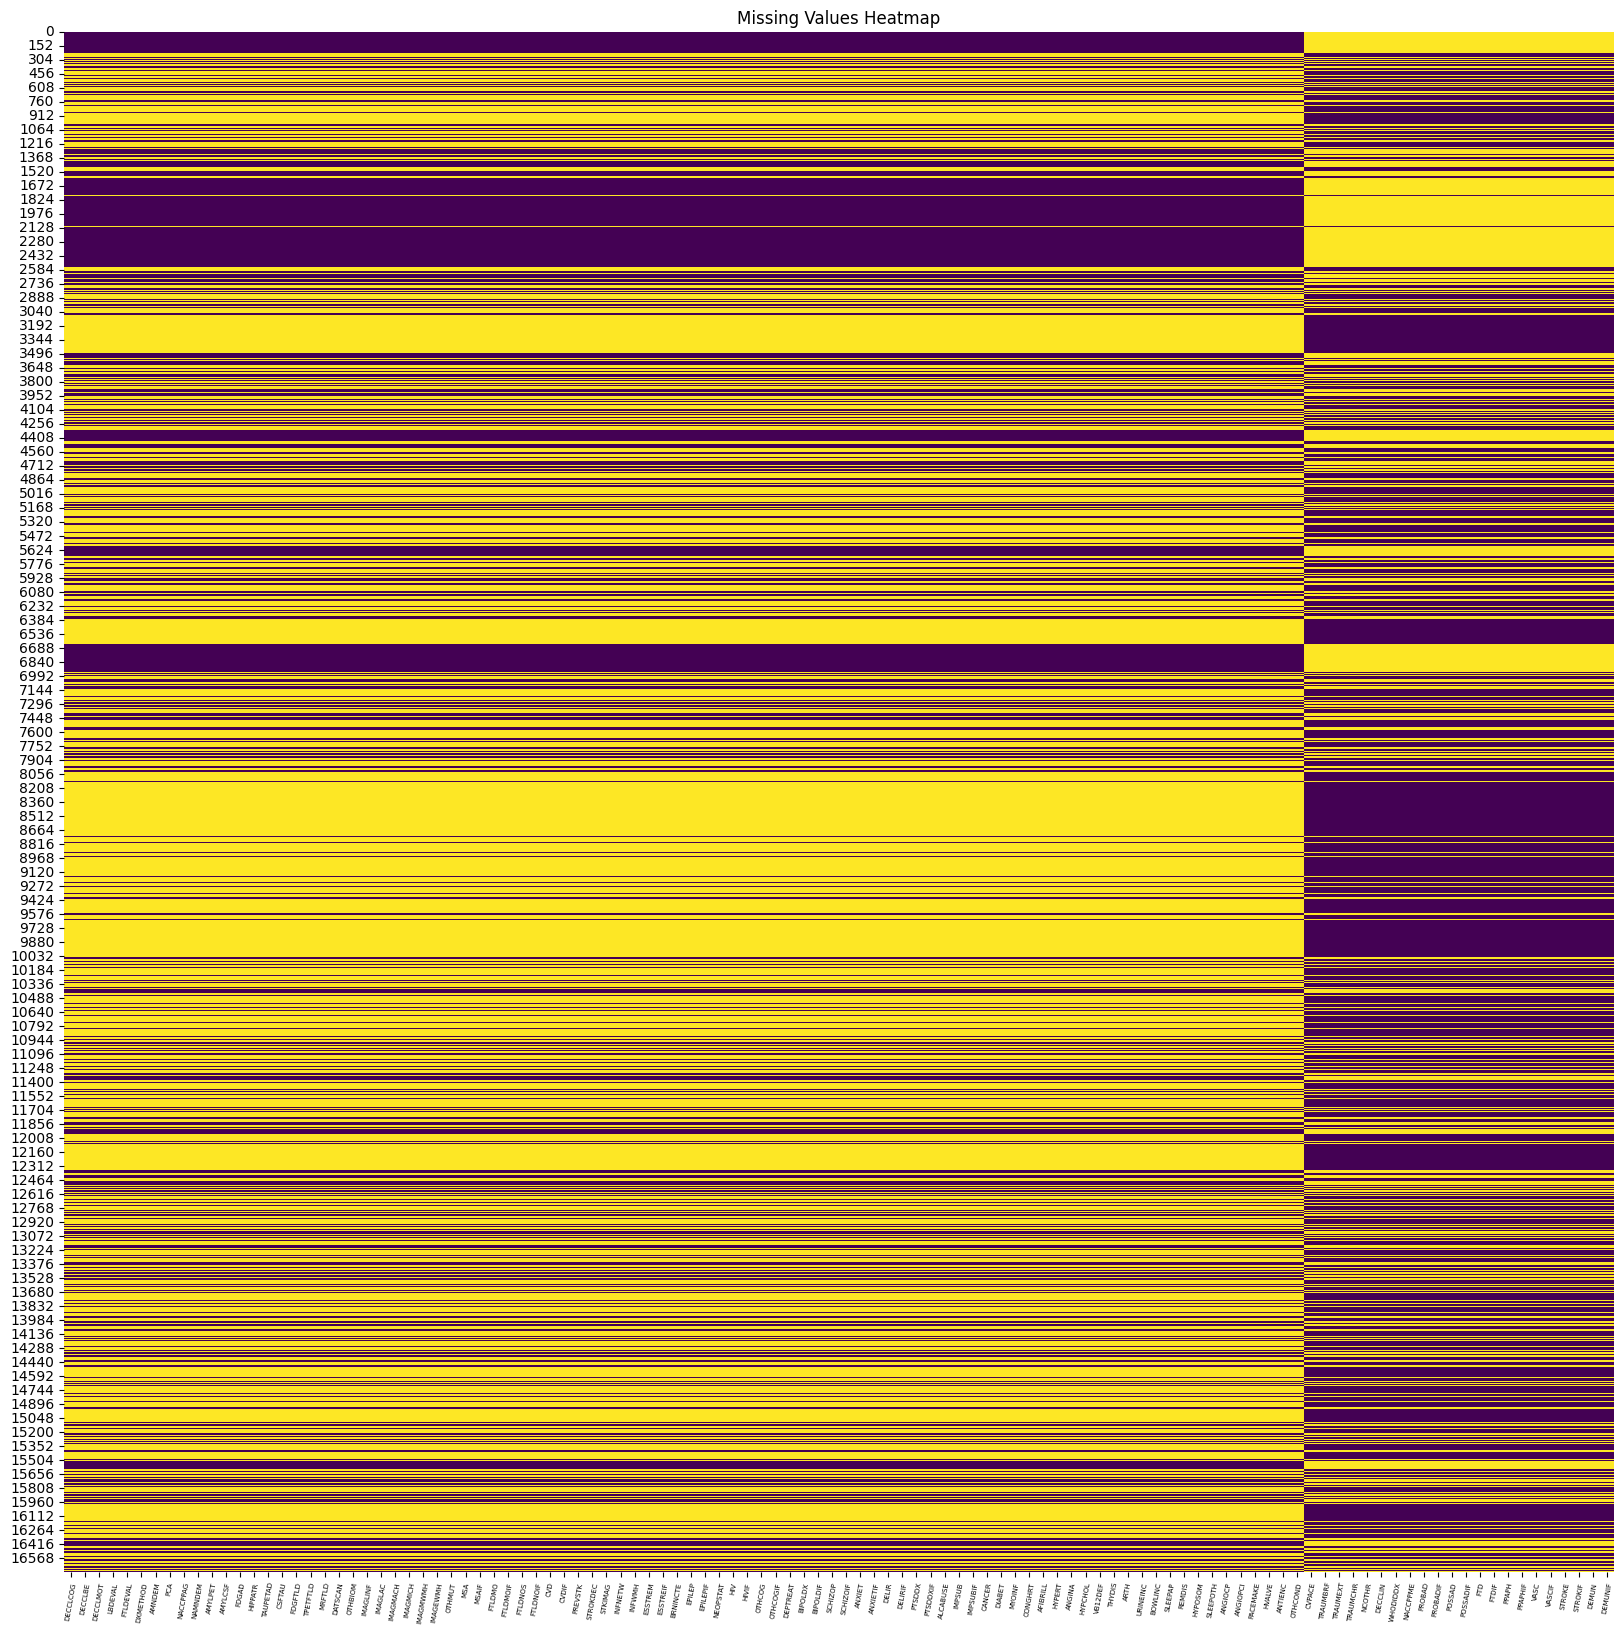

In [28]:
plt.figure(figsize=(20, 20))
sns.heatmap(cleaned_nacc_nan[same_pattern_columns + opposite_pattern_columns].isna(), cbar=False, cmap='viridis')
plt.xticks(rotation=80, fontsize=5)
plt.title('Missing Values Heatmap')
plt.show()

In [29]:
same_pattern_columns

['DECCLCOG',
 'DECCLBE',
 'DECCLMOT',
 'LBDEVAL',
 'FTLDEVAL',
 'DXMETHOD',
 'AMNDEM',
 'PCA',
 'NACCPPAG',
 'NAMNDEM',
 'AMYLPET',
 'AMYLCSF',
 'FDGAD',
 'HIPPATR',
 'TAUPETAD',
 'CSFTAU',
 'FDGFTLD',
 'TPETFTLD',
 'MRFTLD',
 'DATSCAN',
 'OTHBIOM',
 'IMAGLINF',
 'IMAGLAC',
 'IMAGMACH',
 'IMAGMICH',
 'IMAGMWMH',
 'IMAGEWMH',
 'OTHMUT',
 'MSA',
 'MSAIF',
 'FTLDMO',
 'FTLDMOIF',
 'FTLDNOS',
 'FTLDNOIF',
 'CVD',
 'CVDIF',
 'PREVSTK',
 'STROKDEC',
 'STKIMAG',
 'INFNETW',
 'INFWMH',
 'ESSTREM',
 'ESSTREIF',
 'BRNINCTE',
 'EPILEP',
 'EPILEPIF',
 'NEOPSTAT',
 'HIV',
 'HIVIF',
 'OTHCOG',
 'OTHCOGIF',
 'DEPTREAT',
 'BIPOLDX',
 'BIPOLDIF',
 'SCHIZOP',
 'SCHIZOIF',
 'ANXIET',
 'ANXIETIF',
 'DELIR',
 'DELIRIF',
 'PTSDDX',
 'PTSDDXIF',
 'ALCABUSE',
 'IMPSUB',
 'IMPSUBIF',
 'CANCER',
 'DIABET',
 'MYOINF',
 'CONGHRT',
 'AFIBRILL',
 'HYPERT',
 'ANGINA',
 'HYPCHOL',
 'VB12DEF',
 'THYDIS',
 'ARTH',
 'URINEINC',
 'BOWLINC',
 'SLEEPAP',
 'REMDIS',
 'HYPOSOM',
 'SLEEPOTH',
 'ANGIOCP',
 'ANGIOPCI',
 'PACEMA

In [30]:
len(same_pattern_columns), len(opposite_pattern_columns)

(88, 22)

In [31]:
columns_to_continue = columns_with_small_amount_of_nan + same_pattern_columns + opposite_pattern_columns
len(columns_to_continue)

323

In [32]:
nacc_df = nacc_raw.copy()[columns_to_continue]
len(nacc_df.columns.tolist())

323

In [33]:
nacc_df["group"] = np.where(nacc_df['AMYLCSF'].isna(), 2, 1)
nacc_df.head()

,NACCID,VISITMO,VISITDAY,VISITYR,NACCREFR,SEX,HISPANIC,RACE,PRIMLANG,EDUC,...,FTDIF,PPAPH,PPAPHIF,VASC,VASCIF,STROKE,STROKIF,DEMUN,DEMUNIF,group
0,NACC004687,11,14,2022,2.0,1,1.0,1.0,1.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,NACC021466,5,16,2023,2.0,2,1.0,1.0,1.0,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,NACC023914,11,16,2023,1.0,1,0.0,1.0,1.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,NACC038914,8,11,2022,2.0,1,1.0,1.0,1.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,NACC048580,10,19,2023,2.0,2,0.0,1.0,1.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [34]:
nan_nacc_percentage = nacc_raw.isna().sum() / len(nacc_raw) * 100
columns_with_significant_amount_of_nan = nan_nacc_percentage[nan_nacc_percentage > 20].index.tolist()
print(f"Columns with 20%+ number of missing values:\n{columns_with_significant_amount_of_nan}")

Columns with 20%+ number of missing values:
['HISPOR', 'HISPORX', 'RACEX', 'RACESEC', 'RACESECX', 'RACETER', 'RACETERX', 'PRIMLANX', 'NEWINF', 'INHISPOR', 'INHISPOX', 'INRACEX', 'INRASEC', 'INRASECX', 'INRATER', 'INRATERX', 'INRELTOX', 'INKNOWN', 'INVISITS', 'INCALLS', 'NACCAM', 'NACCAMX', 'NACCAMS', 'NACCAMSX', 'NACCFM', 'NACCFMX', 'NACCFMS', 'NACCFMSX', 'NACCOM', 'NACCOMX', 'NACCOMS', 'NACCOMSX', 'DRUG3', 'DRUG4', 'DRUG5', 'DRUG6', 'DRUG7', 'DRUG8', 'DRUG9', 'DRUG10', 'DRUG11', 'DRUG12', 'DRUG13', 'DRUG14', 'DRUG15', 'DRUG16', 'DRUG17', 'DRUG18', 'DRUG19', 'DRUG20', 'DRUG21', 'DRUG22', 'DRUG23', 'DRUG24', 'DRUG25', 'DRUG26', 'DRUG27', 'DRUG28', 'DRUG29', 'DRUG30', 'DRUG31', 'DRUG32', 'DRUG33', 'DRUG34', 'DRUG35', 'DRUG36', 'DRUG37', 'DRUG38', 'DRUG39', 'DRUG40', 'QUITSMOK', 'ALCOCCAS', 'ALCFREQ', 'HATTMULT', 'HATTYEAR', 'CVPACDEF', 'CVPACE', 'CVANGINA', 'CVHVALVE', 'CVOTHRX', 'STROKMUL', 'NACCSTYR', 'TIAMULT', 'NACCTIYR', 'PDYR', 'PDOTHRYR', 'TBI', 'TBIBRIEF', 'TRAUMBRF', 'TBIEXTEN',

In [35]:
cleaned_nacc = nacc_raw.drop(columns=columns_with_significant_amount_of_nan)
len(nacc_raw.columns.tolist())

862

In [36]:
nacc_raw.shape

(16716, 862)

In [37]:
nacc_raw.select_dtypes(include=['object', "string"]).columns

Index(['NACCID', 'HISPORX', 'RACEX', 'RACESECX', 'RACETERX', 'PRIMLANX',
       'INHISPOX', 'INRACEX', 'INRASECX', 'INRATERX',
       ...
       'NACCWRI2', 'NACCWRI3', 'NPFAUT1', 'NPFAUT2', 'NPFAUT3', 'NPFAUT4',
       'NPFHSPEC', 'NPOTH1X', 'NPOTH2X', 'NPOTH3X'],
      dtype='object', length=134)

In [38]:
len(nacc_raw.select_dtypes(include=['number']).columns.tolist())

728

In [39]:
columns_type = []

for col in nacc_raw.columns:
  columns_type.append(nacc_raw[col].dtype)

list(set(columns_type))

[dtype('float64'), dtype('O'), dtype('int64')]

It is seen the there is only one column represented as categorical data, which is the NACCID. We do not need to convert categorical data

In [40]:
no_variance_columns = []

for col in nacc_df.columns:
  col_unique = nacc_df[col].unique()
  if len(col_unique) == 1:
    print(f"{col} has only 1 unique value: {col_unique}")
    no_variance_columns.append(col)
  if len(col_unique) == 2:
    has_nan = pd.isna(col_unique).any()
    if has_nan:
      print(f"{col} has only 1 unique value and NaN: {col_unique}")
      no_variance_columns.append(col)

HUNT has only 1 unique value: [0]
PRION has only 1 unique value: [0]
NACCPPAG has only 1 unique value and NaN: [ 8. nan]
NAMNDEM has only 1 unique value and NaN: [ 8. nan]


In [41]:
nacc_df.drop(columns=no_variance_columns, inplace=True)

# Analyse imbalance

In [42]:
nacc_df.groupby("SEX")['SEX'].agg("count")

SEX
1     5909
2    10807
Name: SEX, dtype: int64

In [43]:
nacc_df.groupby("SEX")['SEX'].agg("count") / nacc_df.shape[0] * 100

SEX
1    35.349366
2    64.650634
Name: SEX, dtype: float64

In [44]:
balance = []
for col in nacc_df.columns:
  if len(nacc_df[col].unique()) == 2:
    balance.append({"column": col, "percentages": nacc_df.groupby(col)[col].agg("count") / nacc_df.shape[0], "vals": nacc_df.groupby(col)[col].agg("count")})

len(balance)

30

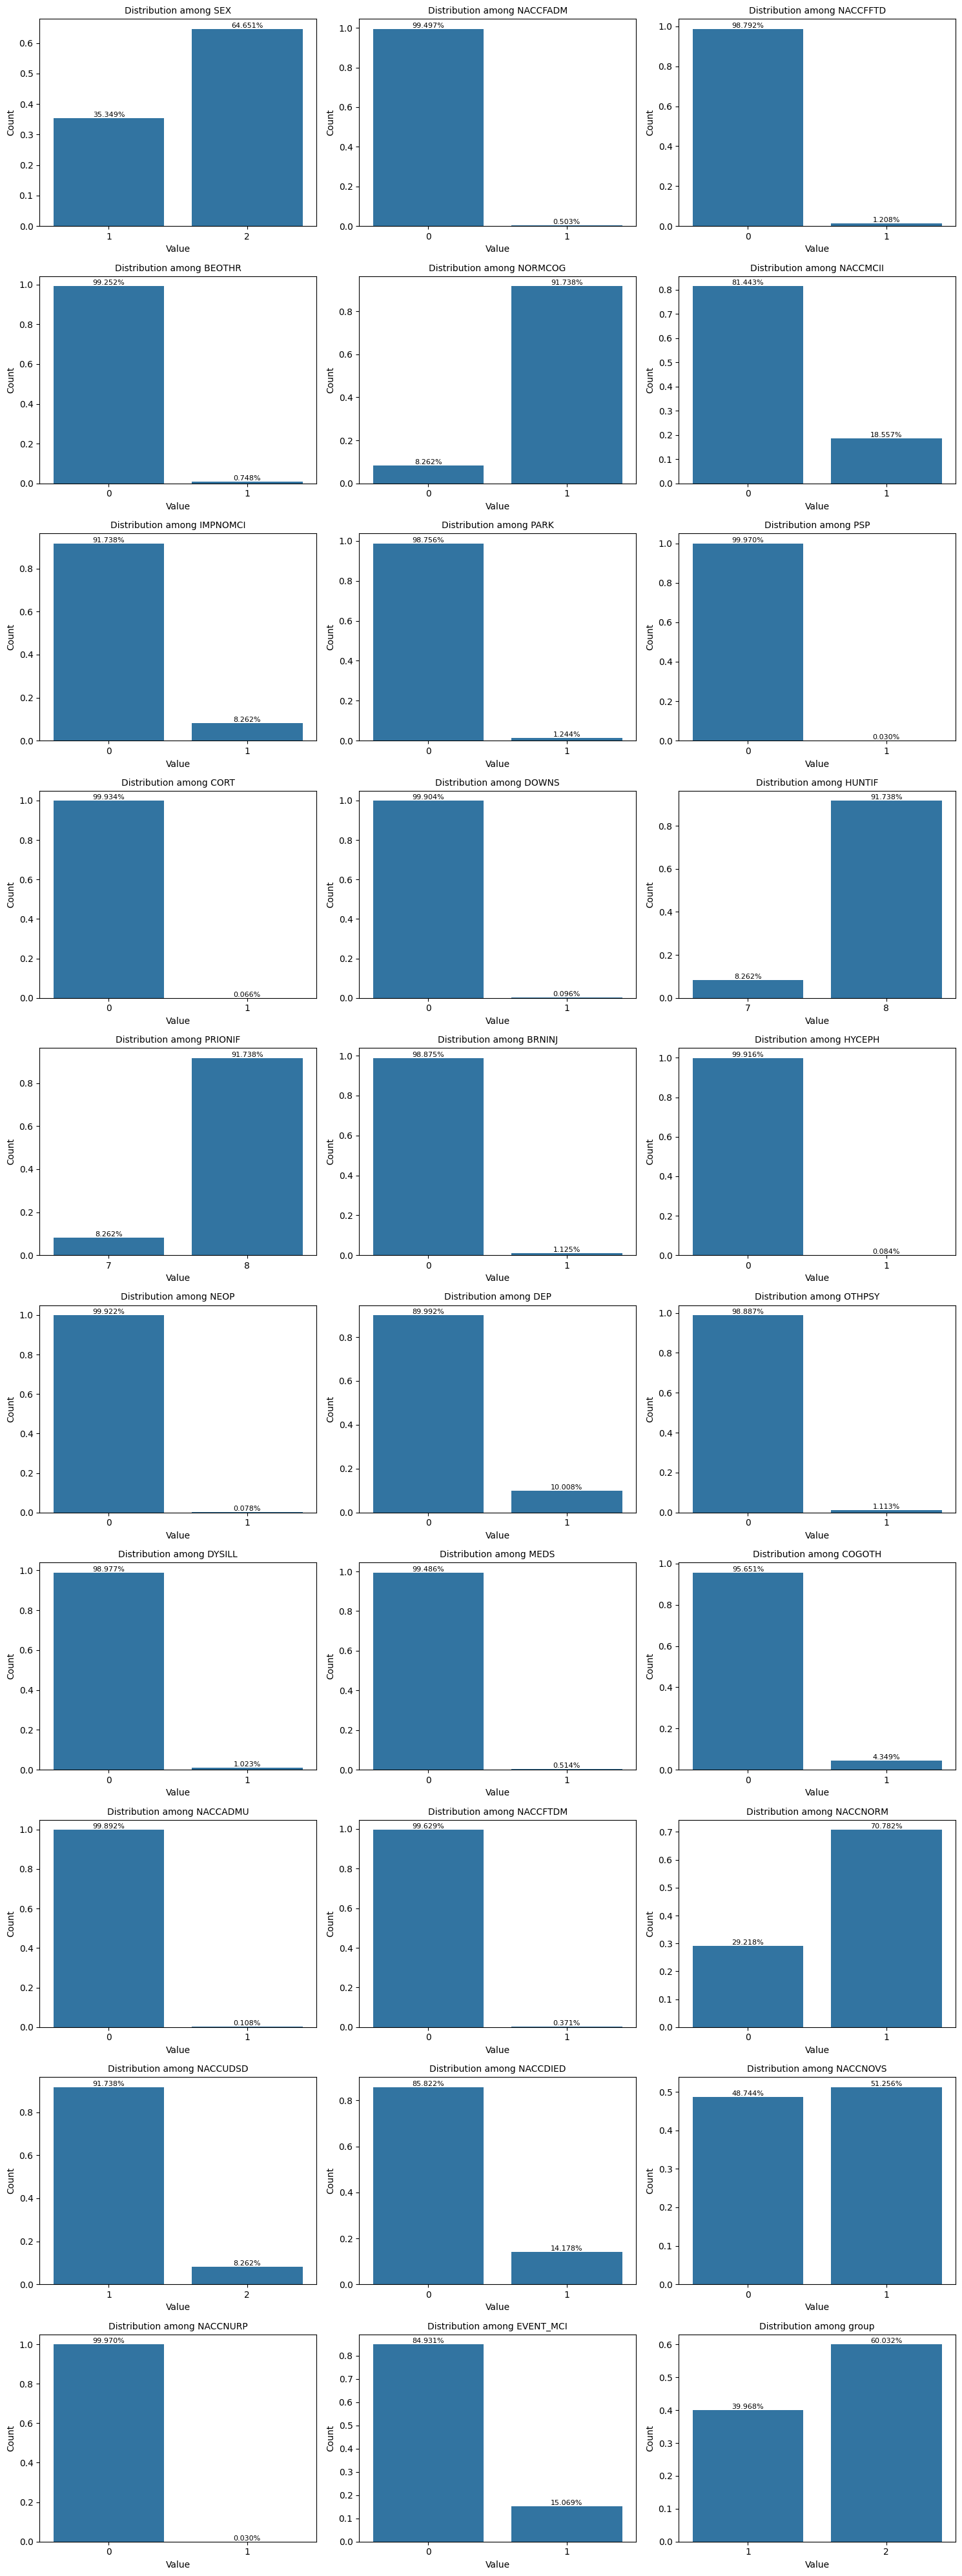

In [ ]:
import math

n_cols = 3
n_rows = math.ceil(len(balance) / n_cols)

fix, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, item in enumerate(balance):
  ax = axes[i]
  df = item["percentages"]

  sns.barplot(df, ax=ax)
  ax.set_title(f"Distribution among {item["column"]}", fontsize=10)
  ax.set_xlabel("Value")
  ax.set_ylabel("Count")

  ax.bar_label(
        ax.containers[0],
        labels=[f"{v * 100:.3f}%" for v in df.values],
        fontsize=8,
    )


plt.tight_layout()

In [46]:
low_variance_columns = []

for bal in balance:
  values = bal["percentages"].values
  if values[0] < 0.009 or values[1] < 0.009:
    print(f"{bal["column"]} has low variance {values} {bal['vals'].values}")

NACCFADM has low variance [0.99497487 0.00502513] [16632    84]
BEOTHR has low variance [0.99252213 0.00747787] [16591   125]
PSP has low variance [9.99700885e-01 2.99114621e-04] [16711     5]
CORT has low variance [9.99341948e-01 6.58052166e-04] [16705    11]
DOWNS has low variance [9.99042833e-01 9.57166786e-04] [16700    16]
HYCEPH has low variance [9.99162479e-01 8.37520938e-04] [16702    14]
NEOP has low variance [9.99222302e-01 7.77698014e-04] [16703    13]
MEDS has low variance [0.99485523 0.00514477] [16630    86]
NACCADMU has low variance [0.99892319 0.00107681] [16698    18]
NACCFTDM has low variance [0.99629098 0.00370902] [16654    62]
NACCNURP has low variance [9.99700885e-01 2.99114621e-04] [16711     5]


In [47]:
nacc_df.drop(columns=low_variance_columns, inplace=True)

In [48]:
len(nacc_df.columns.tolist())

320

In [49]:
nacc_df.drop(columns=['NACCID'], inplace=True)

In [50]:
nacc_df.shape

(16716, 319)

In [51]:
nan_nacc_percentage = nacc_df.isnull().sum() / nacc_df.shape[0] * 100
nan_nacc_percentage.reset_index()
columns_with_small_amount_of_nan = nan_nacc_percentage[nan_nacc_percentage < 20].index.tolist()
nacc_df.dropna(subset=columns_with_small_amount_of_nan, inplace=True)

In [52]:
nacc_df.shape

(7062, 319)

In [53]:
nacc_group_1 = nacc_df[nacc_df['group'] == 1]
nacc_group_2 = nacc_df[nacc_df['group'] == 2]
nacc_group_2.head()

,VISITMO,VISITDAY,VISITYR,NACCREFR,SEX,HISPANIC,RACE,PRIMLANG,EDUC,MARISTAT,...,FTDIF,PPAPH,PPAPHIF,VASC,VASCIF,STROKE,STROKIF,DEMUN,DEMUNIF,group
229,2,24,2010,2.0,1,0.0,3.0,1.0,20.0,1.0,...,8.0,8.0,8.0,8.0,8.0,0.0,8.0,8.0,8.0,2
238,5,30,2007,1.0,2,0.0,1.0,1.0,18.0,1.0,...,8.0,8.0,8.0,8.0,8.0,0.0,8.0,8.0,8.0,2
241,12,12,2014,1.0,1,0.0,1.0,1.0,20.0,1.0,...,8.0,8.0,8.0,8.0,8.0,0.0,8.0,8.0,8.0,2
242,8,9,2006,1.0,2,0.0,1.0,1.0,17.0,1.0,...,8.0,8.0,8.0,8.0,8.0,0.0,8.0,8.0,8.0,2
244,11,19,2012,1.0,1,1.0,1.0,1.0,18.0,2.0,...,8.0,8.0,8.0,8.0,8.0,0.0,8.0,8.0,8.0,2


In [54]:
print(f"Percentage of records in the group1 {nacc_group_1.shape[0] / nacc_df.shape[0]}")

Percentage of records in the group1 0.3963466440101954


In [55]:
print(f"Percentage of records in the group2 {nacc_group_2.shape[0] / nacc_df.shape[0]}")

Percentage of records in the group2 0.6036533559898046


# Censoring rate

In [56]:
time_missed = nacc_df[nacc_df['TIME'].isna()]
time_missed.shape[0]

0

In [57]:
event_missed = nacc_df[nacc_df['EVENT_MCI'].isna()]
event_missed.shape[0]

0

In [58]:
wrong_time = nacc_df[nacc_df['TIME'] < 0]
wrong_time.shape[0]

0

In [59]:
wrong_event = nacc_df[~nacc_df['EVENT_MCI'].isin([1,0])]
wrong_event.shape[0]

0

In [60]:
censored_data = nacc_df[nacc_df['EVENT_MCI'] == 0]

censoring_rate = censored_data.shape[0] / nacc_df.shape[0] * 100
print(f"Censoring rate {censoring_rate:.3f}%")

Censoring rate 86.505%


In [61]:
cleaned_nacc = nacc_df.copy()

In [62]:
train_data, test_data = model_selection.train_test_split(
    cleaned_nacc, test_size=0.2, random_state=55552, 
    stratify=cleaned_nacc['EVENT_MCI']
)

train_data, val_data = model_selection.train_test_split(
    train_data, test_size=0.2, random_state=55552,
    stratify=train_data['EVENT_MCI']
)

In [63]:
x_train = train_data.drop(columns=['TIME', 'EVENT_MCI'])
y_train = Surv.from_dataframe('EVENT_MCI', 'TIME', train_data)

[permutation_importance](https://scikit-survival.readthedocs.io/en/stable/user_guide/random-survival-forest.html)

In [64]:
# from sklearn.inspection import permutation_importance

# def select_top_features(x_data, y_data, n_estimators=15):
#     rsf = RandomSurvivalForest(
#         n_estimators=n_estimators,
#         random_state=42,
#         max_features='sqrt'
#     )
#     rsf.fit(x_data, y_data)

#     importance = permutation_importance(rsf, x_data, y_data, n_repeats=8, random_state=42)

#     feature_importance = pd.DataFrame(
#         {
#             k: importance[k]
#             for k in (
#                 "importances_mean",
#                 "importances_std",
#             )
#         },
#         index=x_data.columns
#     ).sort_values(by="importances_mean", ascending=False)

#     return feature_importance

In [65]:
# top_features = select_top_features(x_train, y_train)

In [66]:
# top_features

In [67]:
# top_features_df = top_features.reset_index()

In [68]:
# top_features_df = top_features_df.rename(columns={"index": "feature"})
# top_features_df.head()

In [69]:
# top_20_features = top_features_df.sort_values("importances_mean", ascending=False).head(20)
# top_20_features

In [70]:
def display_feature_importance(feature_importance_df):
  plt.figure(figsize=(10, 8))
  sns.barplot(data=feature_importance_df, y='feature', x='importances_mean', palette='viridis')  
  plt.xlabel('Feature Importance Score', fontsize=12)
  plt.ylabel('Features', fontsize=12)
  plt.tight_layout()
  plt.show()

In [71]:
# display_feature_importance(top_20_features)